In [15]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [16]:
class LensDataset(Dataset):
    CLASS_NAMES = ['no', 'sphere', 'vort']

    def __init__(self, root_dir, img_size=150, augment=False):
        self.samples  = []
        self.img_size = img_size
        self.augment  = augment

        for label, cls in enumerate(self.CLASS_NAMES):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                raise FileNotFoundError(f'Expected class folder: {cls_path}')
            for fname in os.listdir(cls_path):
                if fname.endswith('.npy'):
                    self.samples.append((os.path.join(cls_path, fname), label))

        print(f'Loaded {len(self.samples)} samples from {root_dir}')

    def __len__(self):
        return len(self.samples)

    def _load_image(self, path):
        img = np.load(path).astype(np.float32)
        if img.ndim == 3:
            img = img[0]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self._load_image(path)

        img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
        img_t = F.interpolate(img_t, size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False)
        img_t = img_t.squeeze(0)

        if self.augment:
            if random.random() > 0.5:
                img_t = torch.flip(img_t, dims=[-1])
            if random.random() > 0.5:
                img_t = torch.flip(img_t, dims=[-2])
            k = random.randint(0, 3)
            img_t = torch.rot90(img_t, k=k, dims=[-2, -1])

        return img_t, label

In [18]:
IMG_SIZE   = 150
BATCH_SIZE = 32

TRAIN_DIR = "/kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/train"
VAL_DIR   = "/kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/val"

full_train = LensDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=False)
n_total    = len(full_train)
n_train    = int(0.9 * n_total)
n_test     = n_total - n_train

train_idx, test_idx = torch.utils.data.random_split(
    range(n_total), [n_train, n_test],
    generator=torch.Generator().manual_seed(42))

train_dataset = LensDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=True)
train_dataset = Subset(train_dataset, train_idx.indices)
test_dataset  = Subset(full_train, test_idx.indices)
val_dataset   = LensDataset(VAL_DIR, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train: {len(train_dataset)} | Test (10%): {len(test_dataset)} '
      f'| Val: {len(val_dataset)}')


Loaded 30000 samples from /kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/train
Loaded 30000 samples from /kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/train
Loaded 7500 samples from /kaggle/input/datasets/ankush775/pinn-dataset/dataset_PINN/val
Train: 27000 | Test (10%): 3000 | Val: 7500


In [19]:
class LensWarp(nn.Module):
    """Warp source image by deflection field α via the lens equation."""
    def forward(self, source, alpha):
        B, C, H, W = source.shape
        ys = torch.linspace(-1, 1, H, device=source.device)
        xs = torch.linspace(-1, 1, W, device=source.device)
        grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
        identity = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0).expand(B,-1,-1,-1)
        sample_grid = (identity - alpha.permute(0,2,3,1)).clamp(-1, 1)
        return F.grid_sample(source, sample_grid, mode='bilinear',
                             padding_mode='border', align_corners=True)


class PotentialHead(nn.Module):
    """Learn gravitational potential ψ, derive α=∇ψ and κ=½∇²ψ.
    Uses SIS prior + learned residual. This is the core PINN component."""

    def __init__(self, in_channels=512, img_size=150):
        super().__init__()
        self.img_size = img_size

        # SIS prior: θ_E * r
        self.theta_E_head = nn.Sequential(
            nn.Linear(in_channels, 64), nn.ReLU(True),
            nn.Linear(64, 1), nn.Softplus())

        xs = torch.linspace(-1, 1, img_size)
        ys = torch.linspace(-1, 1, img_size)
        gy, gx = torch.meshgrid(ys, xs, indexing='ij')
        r = torch.sqrt(gx**2 + gy**2 + 1e-6)
        self.register_buffer('r', r.unsqueeze(0).unsqueeze(0))

        # Learned residual potential
        self.residual_net = nn.Sequential(
            nn.Linear(in_channels, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 1, 3, padding=1),
        )
        # Init residual small so SIS dominates early
        nn.init.zeros_(self.residual_net[-1].weight)
        nn.init.zeros_(self.residual_net[-1].bias)

        # Sobel kernels for differentiation
        Kx = torch.tensor([[-1., 0., 1.],
                           [-2., 0., 2.],
                           [-1., 0., 1.]]).view(1,1,3,3) / 8.0
        self.register_buffer('Kx', Kx)
        self.register_buffer('Ky', Kx.transpose(-2,-1).contiguous())

    def forward(self, feat):
        B = feat.size(0)
        # SIS potential
        theta_E = self.theta_E_head(feat)          # (B, 1)
        psi_sis = theta_E.unsqueeze(-1).unsqueeze(-1) * self.r  # (B,1,H,W)

        # Learned residual
        psi_resid = self.residual_net(feat)
        psi_resid = F.interpolate(psi_resid, size=(self.img_size, self.img_size),
                                  mode='bilinear', align_corners=False)
        psi = psi_sis + psi_resid

        # α = ∇ψ (curl-free by construction)
        alpha_x = F.conv2d(psi, self.Kx, padding=1)
        alpha_y = F.conv2d(psi, self.Ky, padding=1)
        alpha = torch.cat([alpha_x, alpha_y], dim=1)

        # κ = ½∇²ψ (Poisson equation by construction)
        d2x = F.conv2d(alpha_x, self.Kx, padding=1)
        d2y = F.conv2d(alpha_y, self.Ky, padding=1)
        kappa = 0.5 * (d2x + d2y)

        return psi, alpha, kappa, theta_E.squeeze(1)


class SourceDecoder(nn.Module):
    """Simple decoder: features → unlensed source image."""

    def __init__(self, in_channels=512, img_size=150):
        super().__init__()
        self.img_size = img_size
        self.net = nn.Sequential(
            nn.Linear(in_channels, 128 * 4 * 4),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64,  32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32,  16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(True),
            nn.ConvTranspose2d(16,   8, 4, 2, 1), nn.BatchNorm2d(8),  nn.ReLU(True),
            nn.Conv2d(8, 1, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, feat):
        src = self.net(feat)
        return F.interpolate(src, size=(self.img_size, self.img_size),
                             mode='bilinear', align_corners=False)


In [20]:
class PINNLensNet(nn.Module):
    """Physics-Informed Lens Classifier.

    Pipeline:
      1. ResNet18 encoder → 512-dim features
      2. PotentialHead   → ψ, α=∇ψ, κ=½∇²ψ (hard physics constraints)
      3. SourceDecoder   → unlensed source image
      4. LensWarp        → reconstruction = warp(source, α)
      5. Classifier      → encoder features + physics scalars → class

    The classifier uses encoder features directly for strong classification,
    augmented with physics scalars (θ_E, |α|, κ_mean, recon_error).
    Reconstruction via the lens equation acts as a physics regularizer."""

    def __init__(self, num_classes=3, img_size=150):
        super().__init__()

        # ResNet18 backbone (pretrained, 1-channel input)
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        orig_conv = backbone.conv1
        new_conv = nn.Conv2d(1, orig_conv.out_channels,
                             kernel_size=orig_conv.kernel_size,
                             stride=orig_conv.stride,
                             padding=orig_conv.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.data = orig_conv.weight.data.mean(dim=1, keepdim=True)
        backbone.conv1 = new_conv
        self.feat_dim = backbone.fc.in_features  # 512
        backbone.fc = nn.Identity()
        self.encoder = backbone

        # Physics heads
        self.potential_head = PotentialHead(self.feat_dim, img_size)
        self.source_decoder = SourceDecoder(self.feat_dim, img_size)
        self.lens_warp      = LensWarp()

        # Classifier: encoder(512) + θ_E(1) + |α|(1) + κ_mean(1) + recon_err(1)
        self.classifier = nn.Sequential(
            nn.Linear(self.feat_dim + 4, 256),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        feat = self.encoder(x)                           # (B, 512)

        psi, alpha, kappa, theta_E = self.potential_head(feat)
        i_src   = self.source_decoder(feat)
        i_recon = self.lens_warp(i_src, alpha)

        # Physics scalars for classifier
        recon_err  = (x - i_recon).pow(2).mean(dim=[1,2,3]).unsqueeze(1)
        alpha_mag  = alpha.abs().mean(dim=[1,2,3]).unsqueeze(1)
        kappa_mean = kappa.mean(dim=[1,2,3]).unsqueeze(1)

        cls_input = torch.cat([feat, theta_E.unsqueeze(1),
                               alpha_mag, kappa_mean, recon_err], dim=1)
        logits = self.classifier(cls_input)

        return logits, i_recon, i_src, alpha, kappa, psi, theta_E


In [21]:
LAMBDA_RECON = 1.0   # Fixed weight for reconstruction loss

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_cls, total_recon, n = 0., 0., 0., 0

    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        logits, i_recon, *_ = model(imgs)

        cls_loss   = criterion(logits, labels)
        recon_loss = F.mse_loss(i_recon, imgs)
        loss       = cls_loss + LAMBDA_RECON * recon_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        B = imgs.size(0)
        total_loss  += loss.item() * B
        total_cls   += cls_loss.item() * B
        total_recon += recon_loss.item() * B
        n += B

    return {'loss': total_loss/n, 'cls': total_cls/n, 'recon': total_recon/n}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    for imgs, labels in tqdm(loader, desc='Eval ', leave=False):
        imgs = imgs.to(device)
        logits, *_ = model(imgs)
        probs = F.softmax(logits, dim=1)
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())
    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    return auc, all_labels, all_probs


In [22]:
model     = PINNLensNet(num_classes=3, img_size=IMG_SIZE).to(device)
criterion = nn.CrossEntropyLoss()

# Lower LR for pretrained encoder, higher for new heads
optimizer = torch.optim.Adam([
    {'params': model.encoder.parameters(),        'lr': 1e-4},
    {'params': model.potential_head.parameters(),  'lr': 5e-4},
    {'params': model.source_decoder.parameters(),  'lr': 5e-4},
    {'params': model.classifier.parameters(),      'lr': 5e-4},
], weight_decay=1e-4)

NUM_EPOCHS = 50
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

total_p = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_p:,}')
print(f'  Encoder:  {sum(p.numel() for p in model.encoder.parameters()):,}')
print(f'  Potential: {sum(p.numel() for p in model.potential_head.parameters()):,}')
print(f'  Source:   {sum(p.numel() for p in model.source_decoder.parameters()):,}')
print(f'  Classifier: {sum(p.numel() for p in model.classifier.parameters()):,}')


Total parameters: 15,050,678
  Encoder:  11,170,240
  Potential: 2,522,178
  Source:   1,225,137
  Classifier: 133,123


In [23]:
history = {'loss': [], 'cls': [], 'recon': [], 'auc': []}
best_auc, best_epoch = 0., 0

for epoch in range(1, NUM_EPOCHS + 1):
    stats = train_epoch(model, train_loader, optimizer, criterion)
    auc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['loss'].append(stats['loss'])
    history['cls'].append(stats['cls'])
    history['recon'].append(stats['recon'])
    history['auc'].append(auc)

    if auc > best_auc:
        best_auc, best_epoch = auc, epoch
        torch.save(model.state_dict(), 'best_pinn_model.pt')
        marker = '  < best'
    else:
        marker = ''

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Loss={stats["loss"]:.4f} '
          f'(cls={stats["cls"]:.4f} recon={stats["recon"]:.4f}) | '
          f'AUC={auc:.4f}{marker}')

print(f'\nBest: Epoch {best_epoch}, AUC={best_auc:.4f}')


Epoch 01/50 | Loss=0.9761 (cls=0.9678 recon=0.0084) | AUC=0.8493  < best


Epoch 02/50 | Loss=0.6188 (cls=0.6136 recon=0.0052) | AUC=0.9319  < best


Epoch 03/50 | Loss=0.4829 (cls=0.4776 recon=0.0053) | AUC=0.9522  < best


Epoch 04/50 | Loss=0.4213 (cls=0.4162 recon=0.0051) | AUC=0.9607  < best


Epoch 05/50 | Loss=0.3765 (cls=0.3718 recon=0.0047) | AUC=0.9712  < best


...

Epoch 46/50 | Loss=0.0714 (cls=0.0700 recon=0.0015) | AUC=0.9927


Epoch 47/50 | Loss=0.0722 (cls=0.0708 recon=0.0014) | AUC=0.9928  < best


Epoch 48/50 | Loss=0.0695 (cls=0.0681 recon=0.0014) | AUC=0.9926


Epoch 49/50 | Loss=0.0672 (cls=0.0657 recon=0.0014) | AUC=0.9928


Epoch 50/50 | Loss=0.0686 (cls=0.0672 recon=0.0014) | AUC=0.9928

Best: Epoch 47, AUC=0.9928


Internal Test AUC (10% holdout): 0.9934


Validation AUC: 0.9928


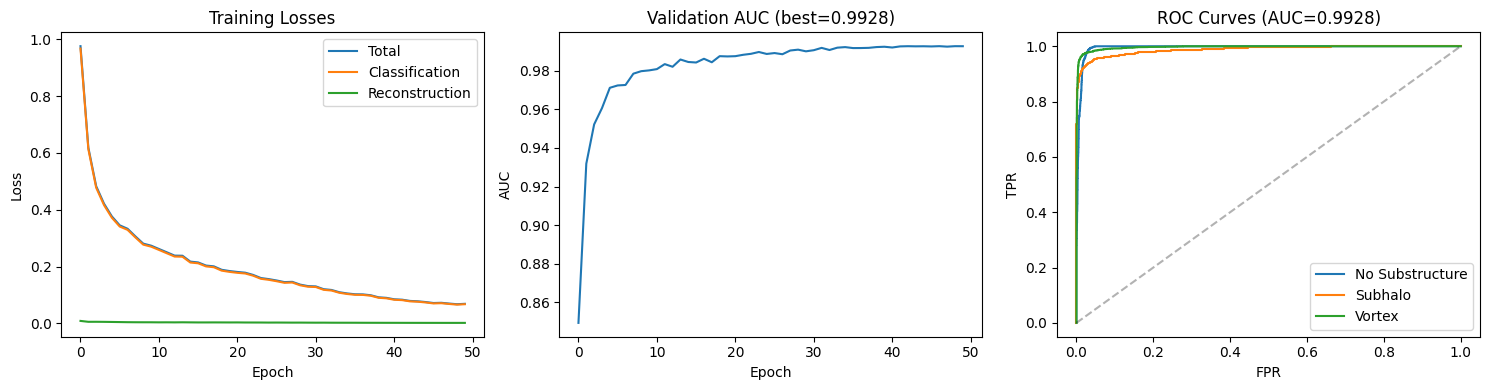

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_pinn_model.pt'))

# Internal test set
test_auc, test_labels, test_probs = evaluate(model, test_loader)
print(f'Internal Test AUC (10% holdout): {test_auc:.4f}')

# Validation set
val_auc, val_labels, val_probs = evaluate(model, val_loader)
print(f'Validation AUC: {val_auc:.4f}')

# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'], label='Total')
axes[0].plot(history['cls'],  label='Classification')
axes[0].plot(history['recon'], label='Reconstruction')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Losses'); axes[0].legend()

axes[1].plot(history['auc'])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title(f'Validation AUC (best={best_auc:.4f})')

# ROC curves
CLASS_NAMES = ['No Substructure', 'Subhalo', 'Vortex']
val_labels_bin = label_binarize(val_labels, classes=[0, 1, 2])
print("\nPer-Class AUC Scores:")
for i, name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(val_labels_bin[:, i], val_probs[:, i])
    auc_i = roc_auc_score(val_labels_bin[:, i], val_probs[:, i])
    print(f"  {name:15s}: {auc_i:.4f}")
    axes[2].plot(fpr, tpr, label=f'{name} ({auc_i:.4f})')
axes[2].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title(f'ROC Curves (Mean AUC={val_auc:.4f})'); axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

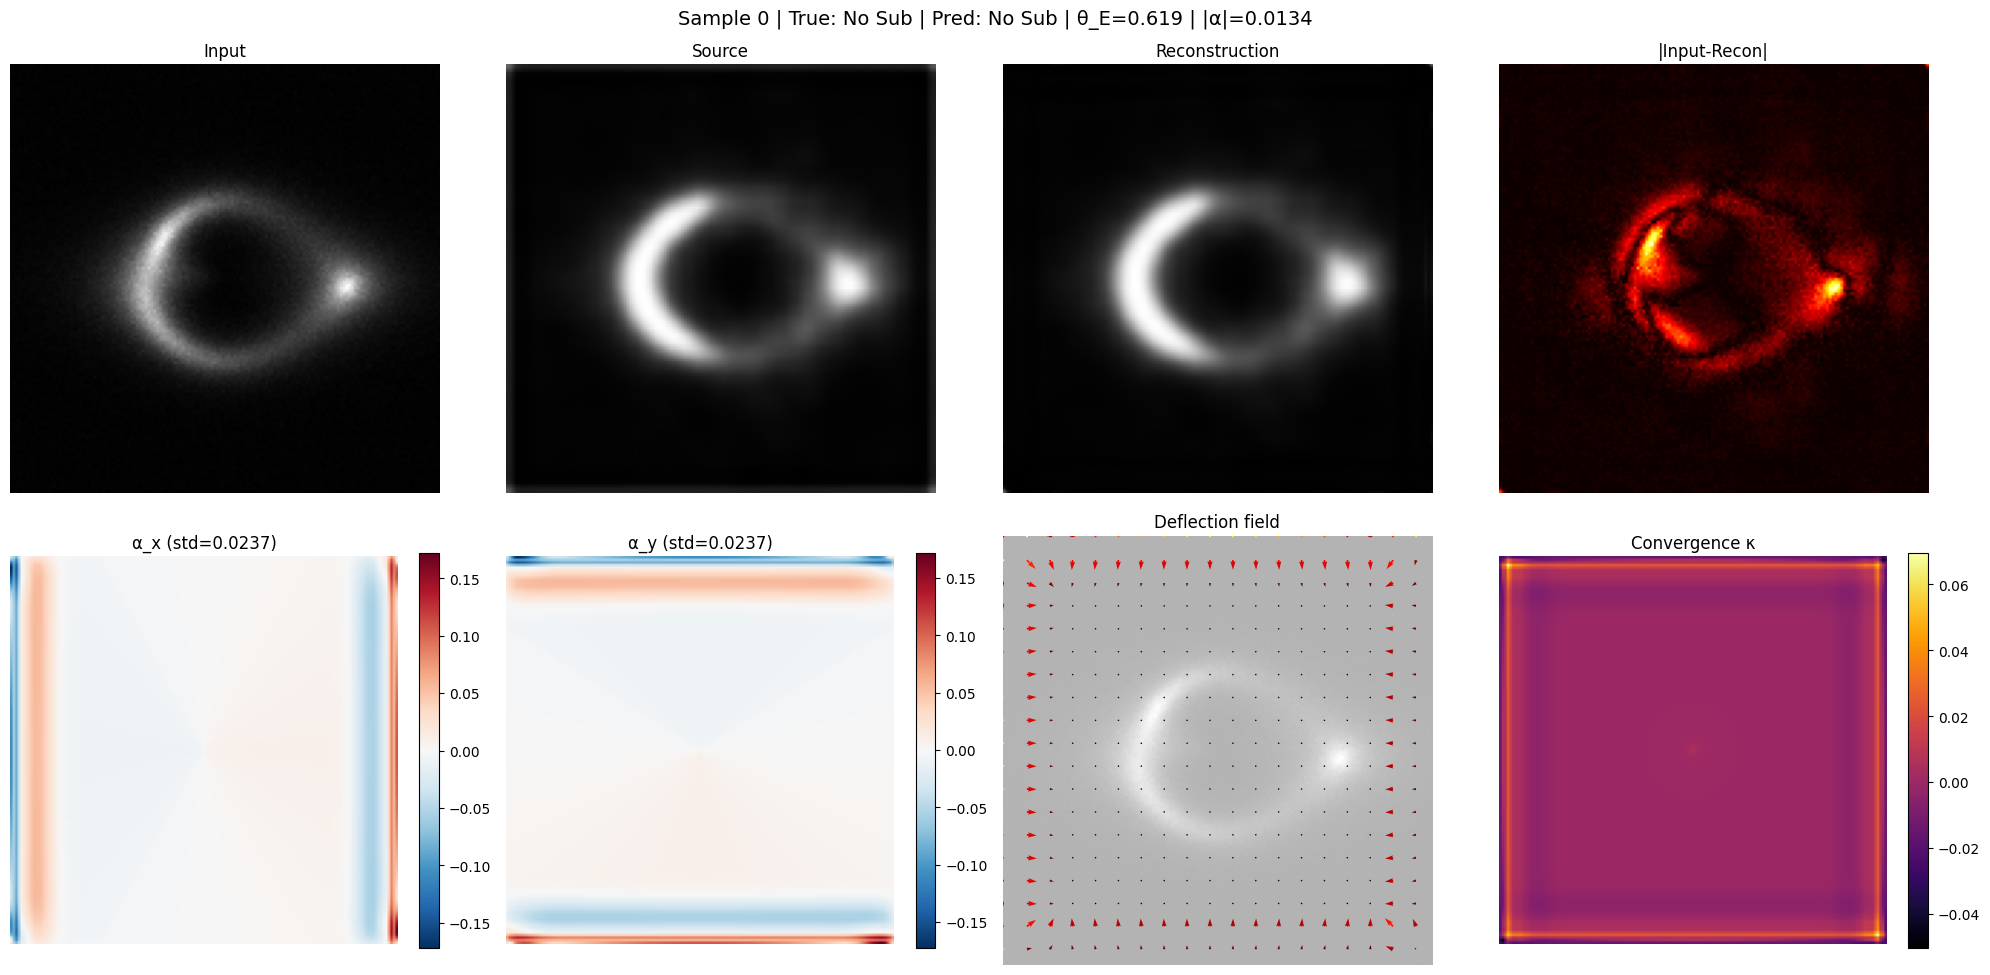

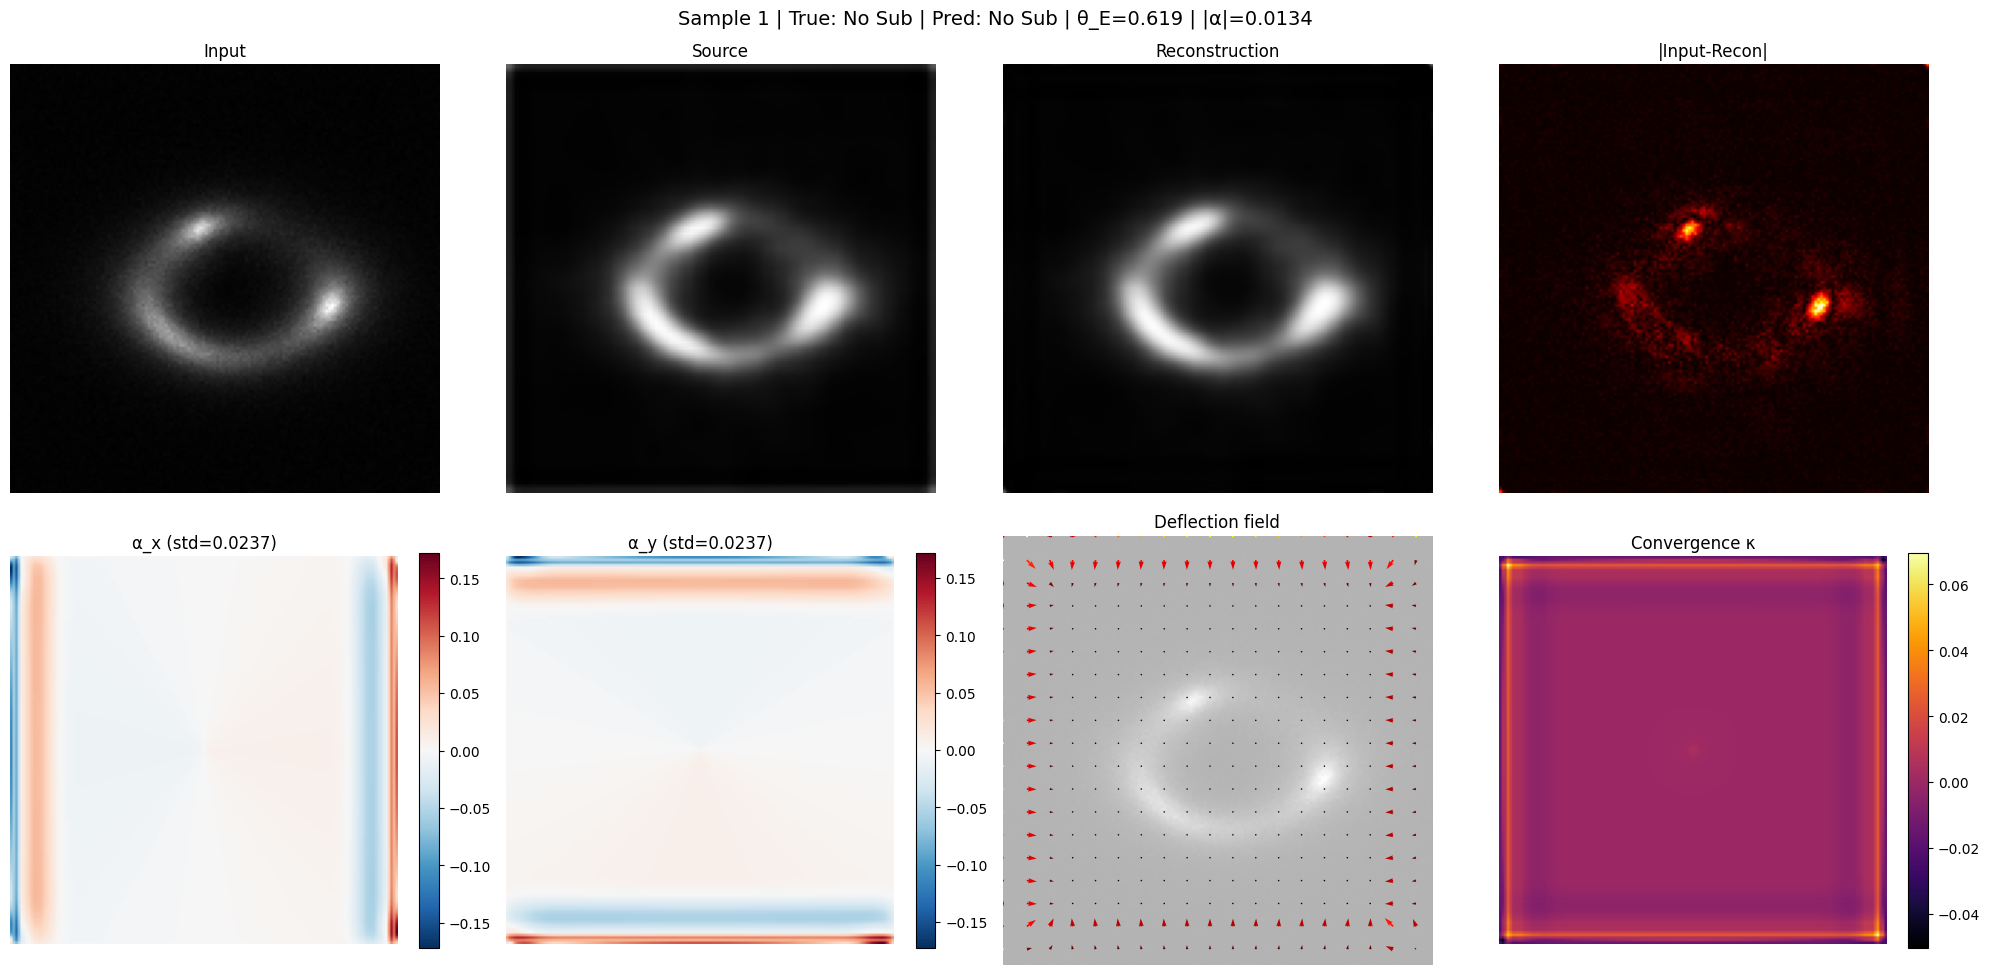

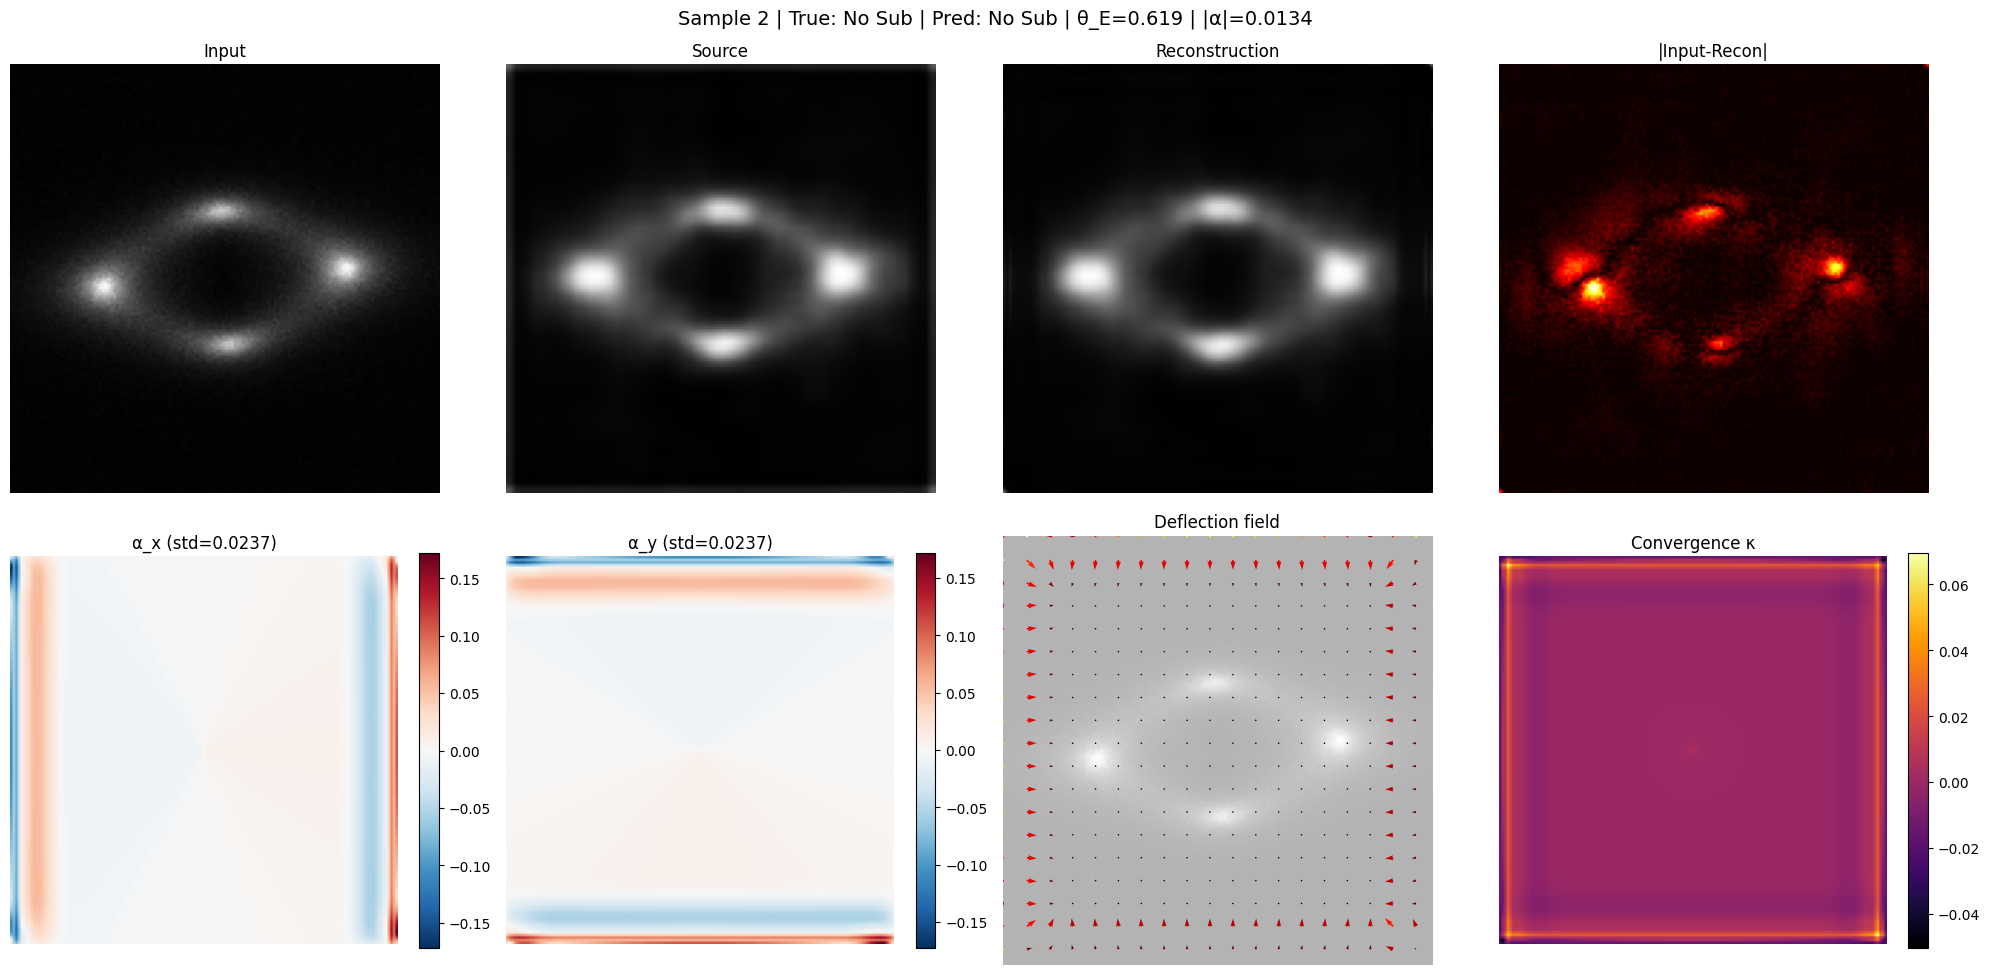

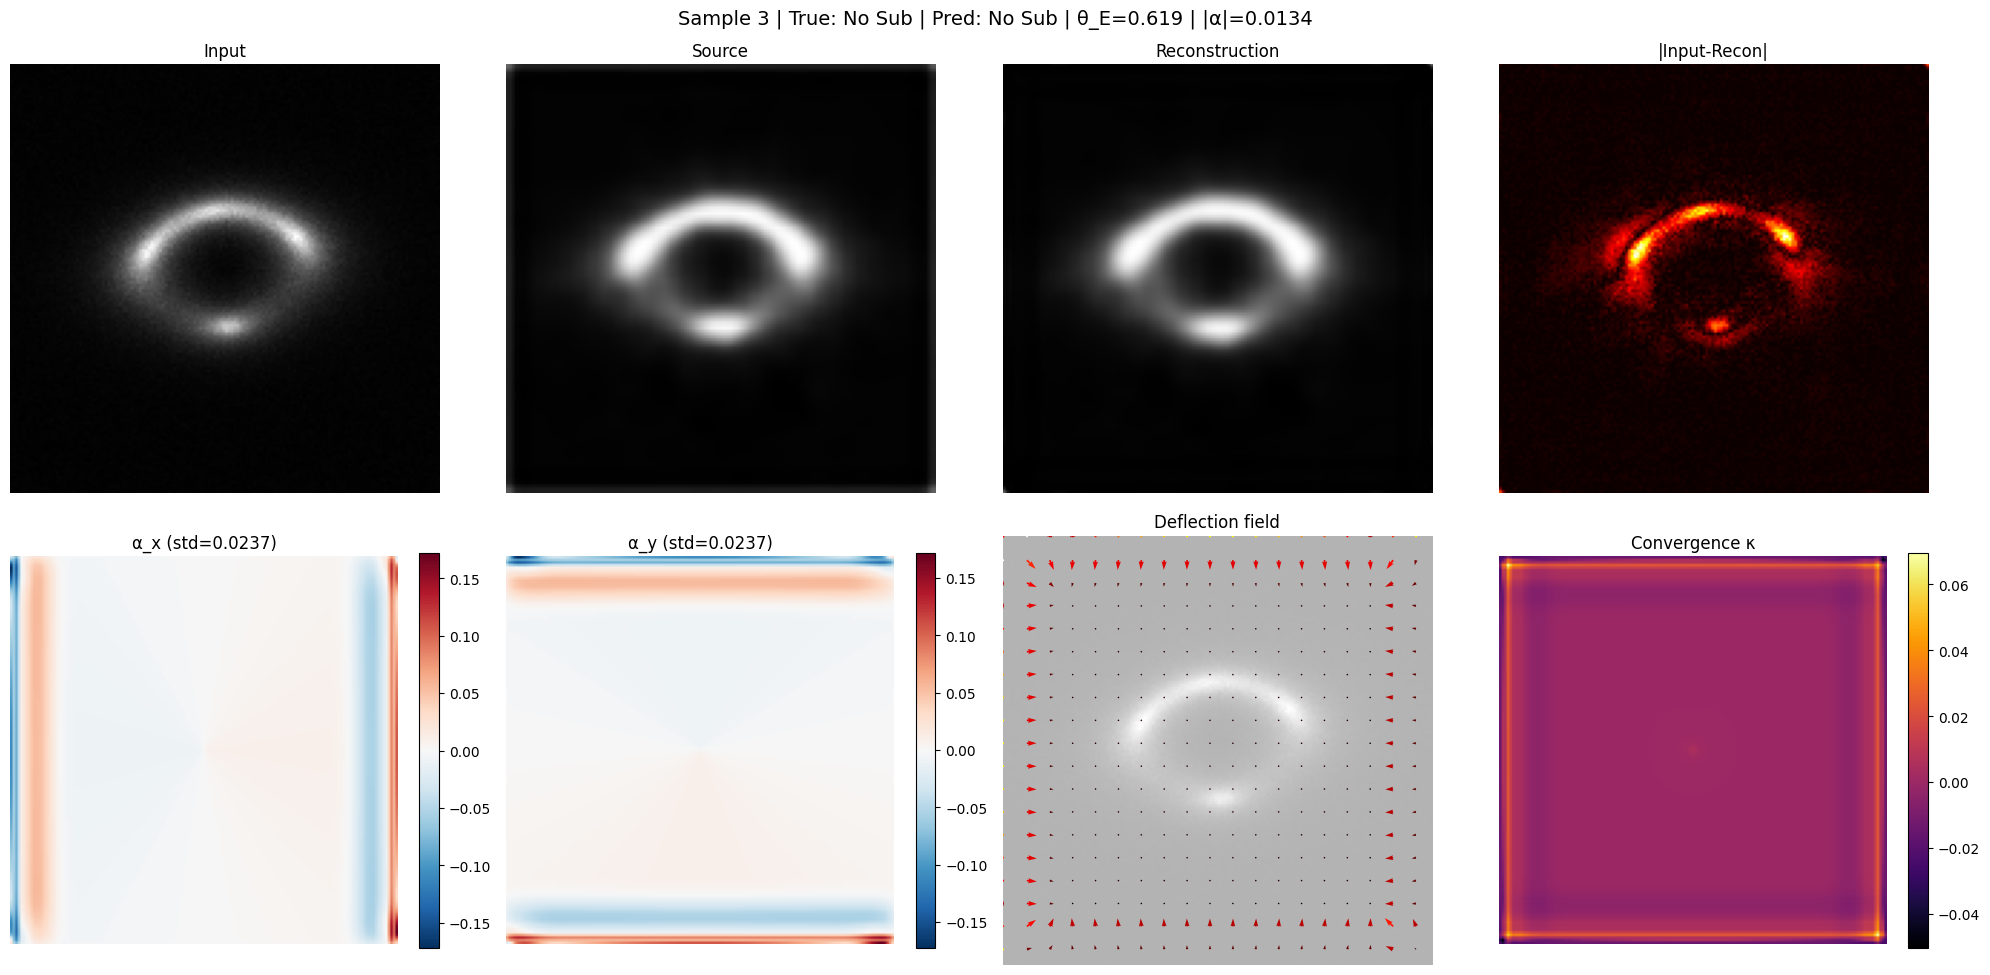

In [25]:
@torch.no_grad()
def visualize_physics(model, dataset, n_samples=4):
    """Show input, source, reconstruction, α_x, α_y, κ for each sample."""
    model.eval()
    CLASS_NAMES = ['No Sub', 'Subhalo', 'Vortex']

    for idx in range(n_samples):
        img, label = dataset[idx]
        x = img.unsqueeze(0).to(device)
        logits, i_recon, i_src, alpha, kappa, psi, theta_E = model(x)
        pred = logits.argmax(1).item()

        inp   = img[0].cpu().numpy()
        src   = i_src[0,0].cpu().numpy()
        rec   = i_recon[0,0].cpu().numpy()
        ax_np = alpha[0,0].cpu().numpy()
        ay_np = alpha[0,1].cpu().numpy()
        k_np  = kappa[0,0].cpu().numpy()

        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle(f'Sample {idx} | True: {CLASS_NAMES[label]} | '
                     f'Pred: {CLASS_NAMES[pred]} | '
                     f'θ_E={theta_E[0].item():.3f} | '
                     f'|α|={alpha.abs().mean().item():.4f}', fontsize=14)

        axes[0,0].imshow(inp, cmap='gray'); axes[0,0].set_title('Input')
        axes[0,1].imshow(src, cmap='gray'); axes[0,1].set_title('Source')
        axes[0,2].imshow(rec, cmap='gray'); axes[0,2].set_title('Reconstruction')
        axes[0,3].imshow(np.abs(inp-rec), cmap='hot'); axes[0,3].set_title('|Input-Recon|')

        im1 = axes[1,0].imshow(ax_np, cmap='RdBu_r'); axes[1,0].set_title(f'α_x (std={ax_np.std():.4f})')
        plt.colorbar(im1, ax=axes[1,0], fraction=0.046)
        im2 = axes[1,1].imshow(ay_np, cmap='RdBu_r'); axes[1,1].set_title(f'α_y (std={ay_np.std():.4f})')
        plt.colorbar(im2, ax=axes[1,1], fraction=0.046)

        # Vector field
        step = 8
        Y, X = np.mgrid[0:ax_np.shape[0]:step, 0:ax_np.shape[1]:step]
        U, V = ax_np[::step,::step], ay_np[::step,::step]
        axes[1,2].imshow(inp, cmap='gray', alpha=0.3)
        axes[1,2].quiver(X, Y, U, -V, np.sqrt(U**2+V**2), cmap='hot',
                         scale=max(np.sqrt(U**2+V**2).max()*15, 1e-6), width=0.004)
        axes[1,2].set_title('Deflection field')

        im3 = axes[1,3].imshow(k_np, cmap='inferno'); axes[1,3].set_title('Convergence κ')
        plt.colorbar(im3, ax=axes[1,3], fraction=0.046)

        for ax in axes.flat: ax.axis('off')
        plt.tight_layout(); plt.show()

visualize_physics(model, val_dataset, n_samples=4)
